In [1]:
import pandas as pd
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.feature_selection.recursive.classifier_cross_validation import ClassifierCrossValidationRecursiveFeatureSelection as classifier

In [2]:
TARGET = 'target_win'
RANDOM_SEED = 32
RFE_XGB_PARAMS = dict(
    n_estimators=5000,
    n_jobs=-1,
    learning_rate=.15,
    early_stopping_rounds=10,
    max_depth=5,
    eval_metric='auc',
    importance_type='total_gain',
    random_state=RANDOM_SEED
)
np.random.seed(RANDOM_SEED)

In [3]:
MODEL_FEATURES_BEFORE_RFE = pd.read_csv(
    '../../../../../data/predict_games/model_features_in/xgb_features_list.csv'
)
INPUT_DATA = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

In [4]:
MODEL_FEATURES_BEFORE_RFE

,feature
0,season
1,week
2,div_game
3,target_days_since_previous_game
4,target_off_cumulative_score
...,...
565,def_target_racr_cumulative_average_rank_change
566,def_target_wopr_cumulative_average_rank_change
567,def_target_special_teams_tds_cumulative_averag...
568,is_home_target


In [5]:
INPUT_DATA

,game_id,season,week,opp_team,opp_score,target_team,target_score,div_game,target_days_since_previous_game,target_off_cumulative_score,...,def_target_rushing_fumbles_lost_cumulative_average_rank_change,def_target_rushing_first_downs_cumulative_average_rank_change,def_target_rushing_epa_cumulative_average_rank_change,def_target_receiving_fumbles_cumulative_average_rank_change,def_target_receiving_fumbles_lost_cumulative_average_rank_change,def_target_racr_cumulative_average_rank_change,def_target_wopr_cumulative_average_rank_change,def_target_special_teams_tds_cumulative_average_rank_change,is_home_target,target_win
0,2003_02_WAS_ATL,2003,2,WAS,33.0,ATL,31.0,0,7.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,2003_02_CLE_BAL,2003,2,CLE,13.0,BAL,33.0,1,7.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
2,2003_02_DET_GB,2003,2,DET,6.0,GB,31.0,1,7.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
3,2003_02_TEN_IND,2003,2,TEN,7.0,IND,33.0,1,7.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
4,2003_02_BUF_JAX,2003,2,BUF,38.0,JAX,17.0,0,7.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10805,2023_18_DEN_LV,2023,18,LV,27.0,DEN,14.0,1,7.0,343.0,...,2.0,0.0,-5.0,-1.0,-1.0,1.0,0.0,0.0,0,0
10806,2023_18_PHI_NYG,2023,18,NYG,27.0,PHI,10.0,1,7.0,423.0,...,0.0,8.0,0.0,-1.0,0.0,0.0,0.0,0.0,0,0
10807,2023_18_LA_SF,2023,18,SF,20.0,LA,21.0,1,7.0,383.0,...,-1.0,-1.0,0.0,-1.0,0.0,2.0,0.0,0.0,0,1
10808,2023_18_DAL_WAS,2023,18,WAS,10.0,DAL,38.0,1,8.0,471.0,...,-2.0,0.0,0.0,-2.0,-2.0,2.0,0.0,0.0,0,1


In [6]:
# Rank-only experiment (PR #28): drop every non-rank feature derived from a cumulative
# value -- the cumulative averages, their week-over-week changes, and the cumulative sums --
# keeping only the rank / rank-change features (plus raw per-game stats and context).
# This removes the highly-correlated source columns so RFE can surface the rank signal
# directly. Set RANK_ONLY = False to restore the full-feature pipeline.
RANK_ONLY = True

candidate_features = list(MODEL_FEATURES_BEFORE_RFE['feature'])
if RANK_ONLY:
    candidate_features = [
        f for f in candidate_features
        if 'cumulative' not in f or f.endswith('_rank') or f.endswith('_rank_change')
    ]

model_inputs_df = INPUT_DATA[candidate_features]
# randomize the data
model_inputs_df = model_inputs_df.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)
model_inputs_df

,season,week,div_game,target_days_since_previous_game,target_off_cumulative_avg_score_rank,target_off_cumulative_avg_score_rank_change,opp_days_since_previous_game,opp_off_cumulative_avg_score_rank,opp_off_cumulative_avg_score_rank_change,target_def_cumulative_avg_points_allowed_rank,...,def_target_rushing_fumbles_lost_cumulative_average_rank_change,def_target_rushing_first_downs_cumulative_average_rank_change,def_target_rushing_epa_cumulative_average_rank_change,def_target_receiving_fumbles_cumulative_average_rank_change,def_target_receiving_fumbles_lost_cumulative_average_rank_change,def_target_racr_cumulative_average_rank_change,def_target_wopr_cumulative_average_rank_change,def_target_special_teams_tds_cumulative_average_rank_change,is_home_target,target_win
0,2008,1,1,240.0,21.0,0.0,240.0,23.0,0.0,28.0,...,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0,1
1,2008,9,0,7.0,27.0,-1.0,7.0,17.0,4.0,25.0,...,0.0,-2.0,1.0,-2.0,-1.0,2.0,-5.0,0.0,1,0
2,2004,10,1,6.0,1.0,0.0,7.0,13.0,3.0,24.0,...,0.0,-3.0,6.0,-1.0,-4.0,0.0,0.0,22.0,1,1
3,2009,15,0,7.0,3.0,-3.0,6.0,18.0,-1.0,16.0,...,8.0,4.0,-2.0,0.0,0.0,2.0,0.0,0.0,1,1
4,2007,17,0,7.0,27.0,-1.0,7.0,17.0,-2.0,18.0,...,1.0,-1.0,0.0,0.0,0.0,-5.0,-5.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10805,2011,10,0,7.0,28.0,3.0,7.0,26.0,4.0,25.0,...,-2.0,1.0,2.0,5.0,0.0,1.0,0.0,0.0,0,1
10806,2022,4,1,7.0,31.0,7.0,7.0,10.0,-3.0,2.0,...,20.0,-4.0,-8.0,5.0,3.0,5.0,0.0,0.0,0,0
10807,2018,15,1,4.0,1.0,0.0,4.0,5.0,-1.0,28.0,...,0.0,0.0,-1.0,-2.0,0.0,0.0,-11.0,0.0,1,0
10808,2019,3,0,7.0,15.0,4.0,7.0,17.0,9.0,16.0,...,0.0,-2.0,0.0,0.0,0.0,7.0,0.0,0.0,0,1


# Create train, test, holdout
We use train at first here until cross validation is ready within a recursive feature elimination framework

In [7]:
# Train is all games before the 2023 season, holdout is 2023
train_df = model_inputs_df[(model_inputs_df['season'] < 2023)]
holdout_df = model_inputs_df[model_inputs_df['season'] == 2023]
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_holdout = holdout_df.drop(columns=[TARGET])
y_holdout = holdout_df[TARGET]

# Begin Recursive Feature Elimination


In [8]:
rfe = classifier(
    X_train, y_train, RFE_XGB_PARAMS, model_score_metric='roc_auc'
)

rfe.get_optimal_features_no_grouped_records(max_iter=20, verbose=1)

Iteration 1 of 20


Iteration 2 of 20


Iteration 3 of 20


Iteration 4 of 20


Iteration 5 of 20


...

Iteration 16 of 20


Iteration 17 of 20


Iteration 18 of 20


Iteration 19 of 20


Iteration 20 of 20


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Number of Features', ylabel='roc_auc'>)

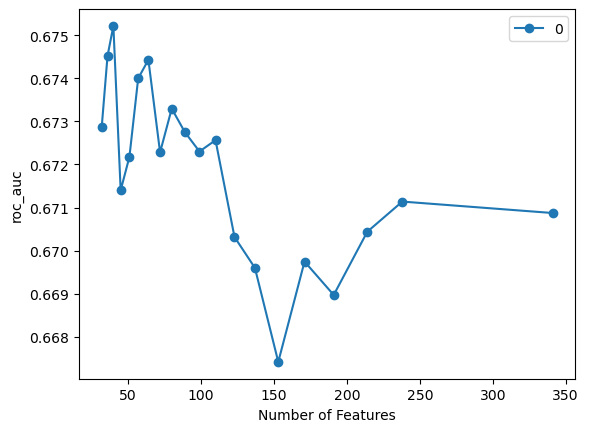

In [9]:
rfe.plot_model_scores()

In [10]:
features_df = rfe.get_features_in_dataframe()
features_df.to_csv('../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv')
features_df

,0,1,2,3,4,5,6,7,8,9,...,331,332,333,334,335,336,337,338,339,340
341,season,week,div_game,target_days_since_previous_game,target_off_cumulative_avg_score_rank,target_off_cumulative_avg_score_rank_change,opp_days_since_previous_game,opp_off_cumulative_avg_score_rank,opp_off_cumulative_avg_score_rank_change,target_def_cumulative_avg_points_allowed_rank,...,def_target_rushing_fumbles_cumulative_average_...,def_target_rushing_fumbles_lost_cumulative_ave...,def_target_rushing_first_downs_cumulative_aver...,def_target_rushing_epa_cumulative_average_rank...,def_target_receiving_fumbles_cumulative_averag...,def_target_receiving_fumbles_lost_cumulative_a...,def_target_racr_cumulative_average_rank_change,def_target_wopr_cumulative_average_rank_change,def_target_special_teams_tds_cumulative_averag...,is_home_target
238,is_home_target,opp_def_cumulative_avg_points_allowed_rank,target_def_cumulative_avg_points_allowed_rank,target_off_cumulative_avg_score_rank,opp_off_cumulative_avg_score_rank,off_target_passing_epa_cumulative_average_rank,off_opp_dakota_cumulative_average_rank,def_opp_rushing_yards_cumulative_average_rank,off_opp_sacks_cumulative_average_rank,off_opp_passing_epa_cumulative_average_rank,...,None,None,None,None,None,None,None,None,None,None
214,is_home_target,opp_def_cumulative_avg_points_allowed_rank,target_def_cumulative_avg_points_allowed_rank,target_off_cumulative_avg_score_rank,opp_off_cumulative_avg_score_rank,off_target_passing_epa_cumulative_average_rank,off_opp_dakota_cumulative_average_rank,def_opp_rushing_yards_cumulative_average_rank,off_target_sacks_cumulative_average_rank,off_target_passing_epa,...,None,None,None,None,None,None,None,None,None,None
191,is_home_target,target_def_cumulative_avg_points_allowed_rank,opp_off_cumulative_avg_score_rank,off_target_passing_epa_cumulative_average_rank,opp_def_cumulative_avg_points_allowed_rank,target_off_cumulative_avg_score_rank,off_opp_passing_epa_cumulative_average_rank,off_opp_dakota_cumulative_average_rank,def_opp_rushing_yards_cumulative_average_rank,off_opp_interceptions_cumulative_average_rank,...,None,None,None,None,None,None,None,None,None,None
171,is_home_target,opp_off_cumulative_avg_score_rank,off_target_passing_epa_cumulative_average_rank,target_def_cumulative_avg_points_allowed_rank,opp_def_cumulative_avg_points_allowed_rank,target_off_cumulative_avg_score_rank,off_opp_passing_epa_cumulative_average_rank,off_opp_dakota_cumulative_average_rank,def_opp_rushing_yards_cumulative_average_rank,off_opp_interceptions_cumulative_average_rank,...,None,None,None,None,None,None,None,None,None,None
153,target_def_cumulative_avg_points_allowed_rank,is_home_target,off_target_passing_epa_cumulative_average_rank,opp_def_cumulative_avg_points_allowed_rank,opp_off_cumulative_avg_score_rank,target_off_cumulative_avg_score_rank,off_opp_passing_epa_cumulative_average_rank,off_opp_rushing_first_downs_cumulative_average...,off_opp_dakota_cumulative_average_rank,off_target_passing_epa,...,None,None,None,None,None,None,None,None,None,None
137,is_home_target,target_def_cumulative_avg_points_allowed_rank,off_target_passing_epa_cumulative_average_rank,opp_off_cumulative_avg_score_rank,target_off_cumulative_avg_score_rank,opp_def_cumulative_avg_points_allowed_rank,off_opp_passing_epa_cumulative_average_rank,off_opp_dakota_cumulative_average_rank,off_target_passing_epa,off_opp_rushing_first_downs_cumulative_average...,...,None,None,None,None,None,None,None,None,None,None
123,is_home_target,opp_off_cumulative_avg_score_rank,off_target_passing_epa_cumulative_average_rank,opp_def_cumulative_avg_points_allowed_rank,target_def_cumulative_avg_points_allowed_rank,off_opp_dakota_cumulative_average_rank,target_off_cumulative_avg_score_rank,off_opp_passing_epa_cumulative_average_rank,def_opp_rushing_yards_cumulative_average_rank,def_opp_rushing_epa_cumulative_average_rank,...,None,None,None,None,None,None,None,None,None,None
110,is_home_target,target_def_cumulative_avg_points_allowed_rank,opp_off_

In [11]:
best_num_feats = rfe.get_best_num_features(.005)
best_num_feats

32

In [12]:
rfe._get_metric_values()

,0
341,0.670874
238,0.671139
214,0.670439
191,0.668972
171,0.669747
153,0.667419
137,0.669601
123,0.670318
110,0.672564
99,0.672301
